#### Figure 4B. Two-dimensional latent space of FDMOs

/tmp/ipykernel_864216/3741885741.py:47: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels([''] * len(np.arange(-6, 8, 2)))
/tmp/ipykernel_864216/3741885741.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels([''] * len(np.arange(-6, 8, 2)))


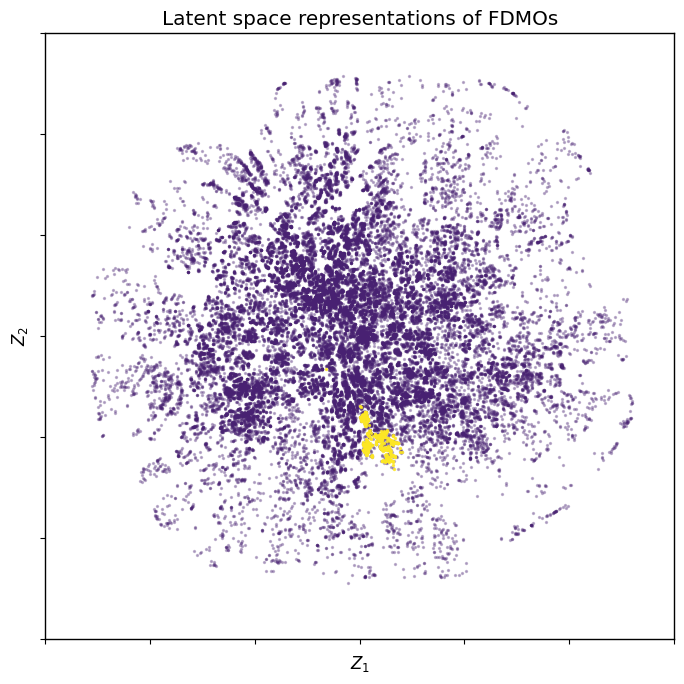

In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import re

# Read latent space representation
with open("../models/FDMO/NoCV_latent_space_d2_layer4_w0.0005_b256_l0.0005_beta1_1000epoch_seed19.pkl", 'rb') as file_handle:
    data = pickle.load(file_handle)
key = data['key']
mu = data['mu']
t_key = data['t_key']
t_mu = data['t_mu']

# Define colors 
purple_color = (0.281, 0.129, 0.449, 1.0)
yellow_color = plt.cm.viridis(1.0)

# Find indices of sequences in t_key matching 'AncXXX_v2' or 'AncXXXa_v2'
pattern = re.compile(r'Anc\d+(?:a)?_v2')
match_indices = [i for i, k in enumerate(t_key) if pattern.fullmatch(k)]
t_mu_match = t_mu[match_indices]

# Plot the latent space
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 12
plt.rcParams['font.weight'] = 'regular'

fig, ax = plt.subplots(figsize=(7, 7))

# Plot sequences in 'key' colored in purple
ax.scatter(mu[:, 0], mu[:, 1], c=[purple_color], alpha=0.3, s=2, label='Sequences in key')

# Plot matched sequences in 't_key' colored in yellow
ax.scatter(t_mu_match[:, 0], t_mu_match[:, 1], c=[yellow_color], alpha=0.8, s=2, label='AncXXX_v2 sequences')

# Customize plot appearance
ax.set_title('Latent space representations of FDMOs')
ax.set_xlabel("$Z_1$", fontsize=12)
ax.set_ylabel("$Z_2$", fontsize=12)
ax.set_xlim((-6, 6))
ax.set_ylim((-6, 6))
# ax.legend()

# Adjust the border line width
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(1)  # Set the desired width (e.g., 2)
ax.set_xticklabels([''] * len(np.arange(-6, 8, 2)))
ax.set_yticklabels([''] * len(np.arange(-6, 8, 2)))
fig.tight_layout()

# Save the figure
fig.savefig('../results/Figure4/PF01494_latent_space_w_anc.png', dpi=300, format='png')
plt.show()


#### Figure 4D. Adjusted mutual information (AMI) between the latent space-based and tree-based clustering

Linkage method: ward
n_clusters = 1, Adjusted Mutual Information (AMI) score: 0.00
n_clusters = 2, Adjusted Mutual Information (AMI) score: 0.37
n_clusters = 3, Adjusted Mutual Information (AMI) score: 0.61
n_clusters = 4, Adjusted Mutual Information (AMI) score: 0.72
n_clusters = 5, Adjusted Mutual Information (AMI) score: 0.71
n_clusters = 6, Adjusted Mutual Information (AMI) score: 0.75
n_clusters = 7, Adjusted Mutual Information (AMI) score: 0.79
n_clusters = 8, Adjusted Mutual Information (AMI) score: 0.77
n_clusters = 9, Adjusted Mutual Information (AMI) score: 0.74
n_clusters = 10, Adjusted Mutual Information (AMI) score: 0.76
n_clusters = 11, Adjusted Mutual Information (AMI) score: 0.75
Linkage method: average
n_clusters = 1, Adjusted Mutual Information (AMI) score: 0.00
n_clusters = 2, Adjusted Mutual Information (AMI) score: 0.37
n_clusters = 3, Adjusted Mutual Information (AMI) score: 0.60
n_clusters = 4, Adjusted Mutual Information (AMI) score: 0.72
n_clusters = 5, Adjuste

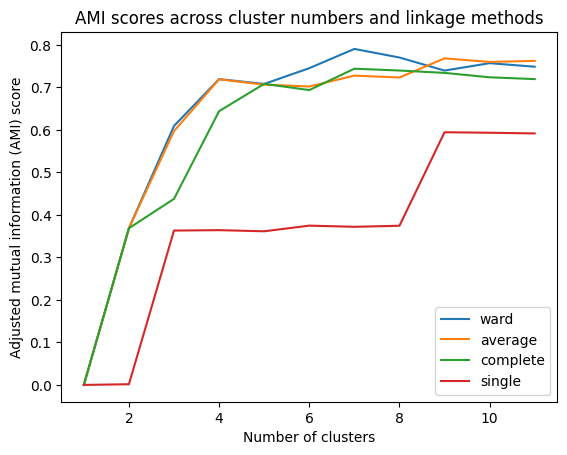

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ete3 import Tree
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics.cluster import adjusted_mutual_info_score

# Read the phylogenetic tree of FDMO (with distance)
t1 = Tree("../data/processed/tree/FDMO/tree-to-reconstruct.newick", format=0)
num_leaf = len(t1)

# Read the cladogram of FDMO (no distance)
t2 = Tree("../data/processed/tree/FDMO/tree-with-ancestors.tree", format=1)

# Label nodes in t1 by t2
for node1, node2 in zip(t1.traverse('preorder'), t2.traverse('preorder')):
    node1.name = node2.name if node2.is_root() or not node2.is_leaf() else node1.name
t1.write(format=1, outfile="../data/processed/tree/FDMO/PF01494_label.newick")

# Calculate distances from the root and record all ancestors of each node, including leaf
for node in t1.traverse('preorder'):
    if node.is_root():
        node.add_feature('anc', [])
        node.add_feature('sumdist', 0)
    else:
        node.add_feature('anc', node.up.anc + [node.up.name])
        node.add_feature('sumdist', node.up.sumdist + node.dist)

# Define head nodes manually for 11 distinct clusters in the tree
head_node_names = ['286', '312', '366', '392', '402', '413', '456', '469', '524', '538', '544']

# Get all descendants of each head node
def get_leaves(head_node_names):
    cluster_node_names = {}
    for name in head_node_names:
        cluster_node_names['Anc' + name] = []
        for node in (t1 & name).traverse('preorder'):
            if not node.is_leaf():
                cluster_node_names['Anc' + name].extend(['Anc' + str(node.name) + '_v2', 'Anc' + str(node.name) + 'a' + '_v2'])
    return cluster_node_names

cluster_node_names = get_leaves(head_node_names)

# Cluster labels and dictionary mapping
cluster_list, cluster_label, cluster_dict = [], [], {}
label = 0
for k, nodes in cluster_node_names.items():
    for i in nodes:
        cluster_list.append(str(i))
        cluster_label.append(label)
        cluster_dict[i] = label
    label += 1

# Read latent space data
with open("../models/FDMO/NoCV_latent_space_d2_layer4_w0.0005_b256_l0.0005_beta1_1000epoch_seed19.pkl", 'rb') as file_handle:
    latent_space = pickle.load(file_handle)
key, mu = latent_space['t_key'], latent_space['t_mu']

# Filter mu by relevant keys
key2muindex, key2label = [], []
for m, k in enumerate(key):
    if k in cluster_list:
        key2muindex.append(m)
        key2label.append(cluster_dict[k])
mu_list = mu[key2muindex]
size_count = len(set(key2label))

# Dictionary to store AMI scores for each linkage type
ami_results = {}

# Perform clustering for different numbers of clusters (from 1 to size_count)
linkage_types = ['ward', 'average', 'complete', 'single']
for linkage in linkage_types:
    print(f"Linkage method: {linkage}")
    ami_scores = []
    for n_clusters in range(1, size_count + 1):
        clustering = AgglomerativeClustering(n_clusters=n_clusters, linkage=linkage).fit(mu_list)
        ami_score = adjusted_mutual_info_score(key2label, clustering.labels_)
        ami_scores.append(ami_score)
        print(f"n_clusters = {n_clusters}, Adjusted Mutual Information (AMI) score: {ami_score:.2f}")
    ami_results[linkage] = ami_scores
    plt.plot(range(1, size_count + 1), ami_scores, label=f'{linkage}')

plt.xlabel('Number of clusters')
plt.ylabel('Adjusted mutual information (AMI) score')
plt.legend()
plt.title('AMI scores across cluster numbers and linkage methods')
plt.savefig("../results/Figure4/AMI_scores_hierachical_clustering.png", dpi=300, format='png')
plt.show()

# Convert AMI results to a DataFrame and save to Excel
df_ami = pd.DataFrame(ami_results, index=range(1, size_count + 1))
df_ami.index.name = 'Number of Clusters'
df_ami.to_excel('../results/Figure4/AMI_scores_latentspaceclustering_w_tree.xlsx', sheet_name='AMI Scores')

#### Figure 4D. Correlation between the evolutionary distances and Euclidean distances in the latent space

Pearson correlation between evolutionary and latent space distances: 0.78, p-value: 2.49e-12


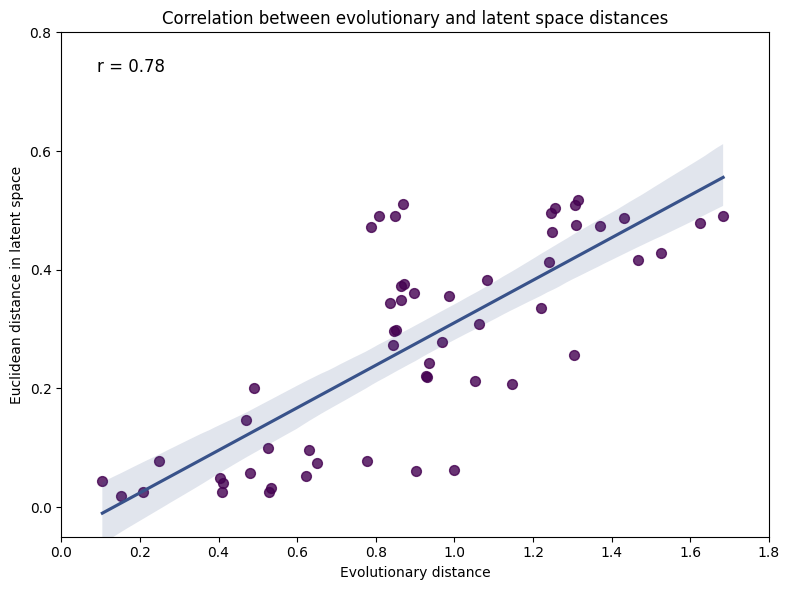

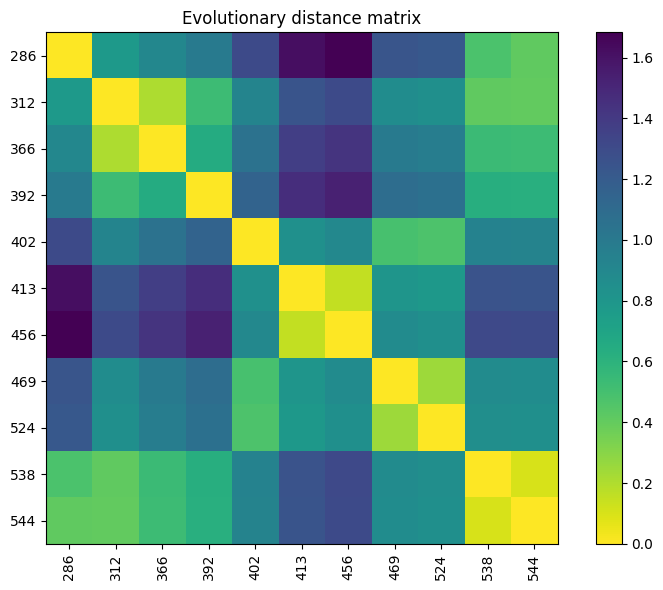

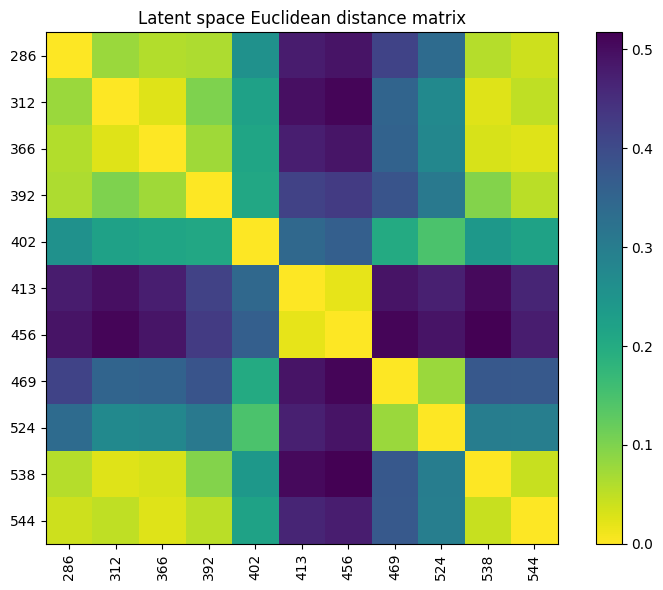

In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ete3 import Tree
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr
from itertools import combinations

# Read the phylogenetic tree of FDMO (with distance)
t1 = Tree("../data/processed/tree/FDMO/tree-to-reconstruct.newick", format=0)
num_leaf = len(t1)

# Read the cladogram of FDMO (no distance)
t2 = Tree("../data/processed/tree/FDMO/tree-with-ancestors.tree", format=1)

# Label nodes in t1 by t2
for node1, node2 in zip(t1.traverse('preorder'), t2.traverse('preorder')):
    node1.name = node2.name if node2.is_root() or not node2.is_leaf() else node1.name
t1.write(format=1, outfile="../data/processed/tree/FDMO/PF01494_label.newick")

# Calculate distances from the root and record all ancestors of each node, including leaf
for node in t1.traverse('preorder'):
    if node.is_root():
        node.add_feature('anc', [])
        node.add_feature('sumdist', 0)
    else:
        node.add_feature('anc', node.up.anc + [node.up.name])
        node.add_feature('sumdist', node.up.sumdist + node.dist)

# Define head nodes manually
head_node_names = ['286', '312', '366', '392', '402', '413', '456', '469', '524', '538', '544']

# Read latent space data
with open("../models/FDMO/NoCV_latent_space_d2_layer4_w0.0005_b256_l0.0005_beta1_1000epoch_seed19.pkl", 'rb') as file_handle:
    latent_space = pickle.load(file_handle)
key, mu = latent_space['t_key'], latent_space['t_mu']

# Ensure each head node has the correct latent space embedding
head_node_mu = []
available_head_nodes = []
for node in head_node_names:
    formatted_name = 'Anc' + node + '_v2'
    if formatted_name in key:
        head_node_mu.append(mu[key.index(formatted_name)])
        available_head_nodes.append(node)  # Keep track of nodes that are available
    else:
        print(f"Warning: Node {formatted_name} not found in latent space keys.")

# Convert head_node_mu to a NumPy array
head_node_mu = np.array(head_node_mu)

# Check if the number of available head nodes matches
if len(available_head_nodes) < len(head_node_names):
    print("Note: Some head nodes were not found in the latent space data.")

# Generate all unique pairs of available head nodes
node_pairs = list(combinations(available_head_nodes, 2))

# Initialize lists to store node pairs and distances
node_pair_list = []
evolutionary_distance_list = []
latent_space_distance_list = []

# Create a mapping from node names to their indices in head_node_mu
node_to_index = {node: idx for idx, node in enumerate(available_head_nodes)}

# Calculate distances for each pair
for node1, node2 in node_pairs:
    # Get evolutionary distance from the tree
    evo_dist = t1.get_distance(node1, node2)
    evolutionary_distance_list.append(evo_dist)
    
    # Get indices for the latent space embeddings
    idx1 = node_to_index[node1]
    idx2 = node_to_index[node2]
    # Calculate Euclidean distance in latent space
    ls_dist = np.linalg.norm(head_node_mu[idx1] - head_node_mu[idx2])
    latent_space_distance_list.append(ls_dist)
    
    # Append node pair to the list
    node_pair_list.append(f"{node1} - {node2}")

# Create a DataFrame with the results
distances_df = pd.DataFrame({
    'Node ID-to-node ID': node_pair_list,
    'Evolutionary distance': evolutionary_distance_list,
    'Euclidean distance in latent space': latent_space_distance_list
})

# Calculate Pearson correlation
correlation, p_value = pearsonr(evolutionary_distance_list, latent_space_distance_list)
print(f"Pearson correlation between evolutionary and latent space distances: {correlation:.2f}, p-value: {p_value:.2e}")

# Output the DataFrame to an Excel file
distances_df.to_excel('../results/Figure4/pairwise_distances.xlsx', index=False, engine='openpyxl')

# Continue with your plotting code...
# Plot 1: Correlation plot
fig1 = plt.figure(figsize=(8, 6))
sns.regplot(
    x=evolutionary_distance_list,
    y=latent_space_distance_list,
    ci=95,
    scatter_kws={"s": 50, "color": (0.265, 0.004, 0.317)},
    line_kws={"color": (0.219, 0.320, 0.543)}
)
plt.xlabel('Evolutionary distance')
plt.ylabel('Euclidean distance in latent space')
plt.title(f'Correlation between evolutionary and latent space distances')
plt.text(0.05, 0.95, f'r = {correlation:.2f}', transform=plt.gca().transAxes, fontsize=12, verticalalignment='top')
plt.xlim(0, 1.8)  # Set x-axis limits
plt.ylim(-0.05, 0.7)  # Set y-axis limits
# Set ticks
plt.xticks(np.arange(0, 2.0, 0.2))
plt.yticks(np.arange(0, 1.0, 0.2))
plt.tight_layout()
fig1.savefig("../results/Figure4/tree_latentspace_distance_correlation.png", dpi=300, format='png')
plt.show()

# Optional: Plotting the evolutionary distance matrix
fig2 = plt.figure(figsize=(8, 6))
plt.imshow(squareform(evolutionary_distance_list), cmap='viridis_r')
plt.colorbar()
plt.title("Evolutionary distance matrix")
plt.xticks(ticks=np.arange(len(available_head_nodes)), labels=available_head_nodes, rotation=90)
plt.yticks(ticks=np.arange(len(available_head_nodes)), labels=available_head_nodes)
plt.tight_layout()
fig2.savefig("../results/Figure4/tree_distances.png", dpi=300, format='png')
plt.show()

# Optional: Plotting the latent space Euclidean distance matrix
fig3 = plt.figure(figsize=(8, 6))
plt.imshow(squareform(latent_space_distance_list), cmap='viridis_r')
plt.colorbar()
plt.title("Latent space Euclidean distance matrix")
plt.xticks(ticks=np.arange(len(available_head_nodes)), labels=available_head_nodes, rotation=90)
plt.yticks(ticks=np.arange(len(available_head_nodes)), labels=available_head_nodes)
plt.tight_layout()
fig3.savefig("../results/Figure4/latentspace_Euclidean_distances.png", dpi=300, format='png')
plt.show()


#### Figure 4E. Color the latent space representations of ancestors based on tree and latent space-based clusterings

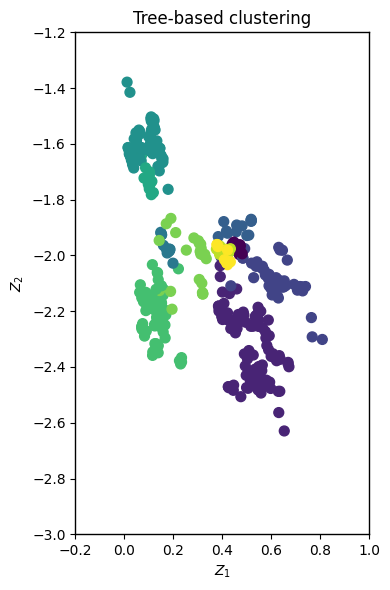

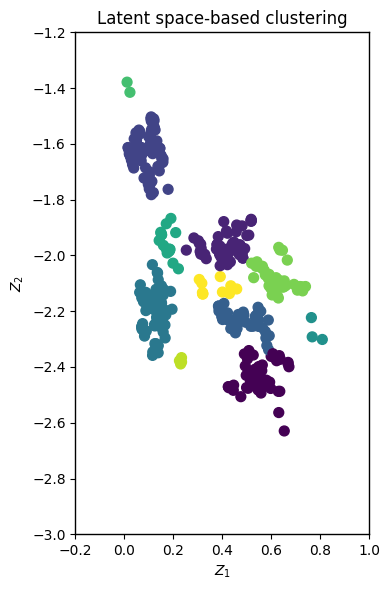

In [3]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from ete3 import Tree
from sklearn.cluster import AgglomerativeClustering

# Read the phylogenetic tree of FDMO (with distance)
t1 = Tree("../data/processed/tree/FDMO/tree-to-reconstruct.newick", format=0)
num_leaf = len(t1)

# Read the cladogram of FDMO (no distance)
t2 = Tree("../data/processed/tree/FDMO/tree-with-ancestors.tree", format=1)

# Label nodes in t1 by t2
for node1, node2 in zip(t1.traverse('preorder'), t2.traverse('preorder')):
    node1.name = node2.name if node2.is_root() or not node2.is_leaf() else node1.name
t1.write(format=1, outfile="../data/processed/tree/FDMO/PF01494_label.newick")

# Calculate distances from the root and record all ancestors of each node, including leaf
for node in t1.traverse('preorder'):
    if node.is_root():
        node.add_feature('anc', [])
        node.add_feature('sumdist', 0)
    else:
        node.add_feature('anc', node.up.anc + [node.up.name])
        node.add_feature('sumdist', node.up.sumdist + node.dist)

# Define head nodes manually
head_node_names = ['286', '312', '366', '392', '402', '413', '456', '469', '524', '538', '544']

# Get all descendants of each head node
def get_leaves(head_node_names):
    cluster_node_names = {}
    for name in head_node_names:
        cluster_node_names['Anc' + name] = []
        for node in (t1 & name).traverse('preorder'):
            if not node.is_leaf():
                cluster_node_names['Anc' + name].extend(['Anc' + str(node.name) + '_v2', 'Anc' + str(node.name) + 'a' + '_v2'])
    return cluster_node_names

cluster_node_names = get_leaves(head_node_names)

# Cluster labels and dictionary mapping for tree-based clusters
cluster_list, cluster_label, cluster_dict = [], [], {}
label = 0
for k, nodes in cluster_node_names.items():
    for i in nodes:
        cluster_list.append(str(i))
        cluster_label.append(label)
        cluster_dict[i] = label
    label += 1

# Read latent space data
with open("../models/FDMO/NoCV_latent_space_d2_layer4_w0.0005_b256_l0.0005_beta1_1000epoch_seed19.pkl", 'rb') as file_handle:
    latent_space = pickle.load(file_handle)
key, mu = latent_space['t_key'], latent_space['t_mu']

# Filter mu by relevant keys and get labels from tree clustering
key2muindex, key2label = [], []
for m, k in enumerate(key):
    if k in cluster_list:
        key2muindex.append(m)
        key2label.append(cluster_dict[k])
mu_list = mu[key2muindex]

# Convert filtered latent space representations to a numpy array for plotting
mu_list = np.array(mu_list)
size_count = len(set(key2label))

# Colored by the tree
fig1, ax1 = plt.subplots(figsize=(4, 6))
scatter1 = ax1.scatter(mu_list[:, 0], mu_list[:, 1], c=key2label, cmap='viridis', s=50)
# Optional: Add a colorbar
# cbar1 = fig1.colorbar(scatter1, ax=ax1)
# cbar1.set_label("Tree Clustering Labels")
ax1.set_title("Tree-based clustering")
ax1.set_xlim(-0.2, 1)  # Set x-axis limits
ax1.set_ylim(-3, -1.2)  # Set y-axis limits
ax1.set_xlabel(r'$Z_1$')
ax1.set_ylabel(r'$Z_2$')

# Hide the tick labels if desired
ax1.tick_params(axis='both', which='both', labelbottom=True, labelleft=True)

# Adjust the border line width
for axis in ['top', 'bottom', 'left', 'right']:
    ax1.spines[axis].set_linewidth(1)  # Set the desired width
plt.tight_layout()
fig1.savefig("../results/Figure4/ancestors_tree_clustering.png", dpi=300, format='png')
plt.show()

# Colored by latent space clustering
# Perform clustering in the latent space
latent_space_clustering = AgglomerativeClustering(n_clusters=len(head_node_names), linkage='average').fit(mu_list)
latent_space_labels = latent_space_clustering.labels_

fig2, ax2 = plt.subplots(figsize=(4, 6))
scatter2 = ax2.scatter(mu_list[:, 0], mu_list[:, 1], c=latent_space_labels, cmap='viridis', s=50)
# Optional: Add a colorbar
# cbar2 = fig2.colorbar(scatter2, ax=ax2)
# cbar2.set_label("Latent Space Clustering Labels")
ax2.set_title("Latent space-based clustering")
ax2.set_xlim(-0.2, 1)  # Set x-axis limits
ax2.set_ylim(-3, -1.2)  # Set y-axis limits
ax2.set_xlabel(r'$Z_1$')
ax2.set_ylabel(r'$Z_2$')

# Hide the tick labels if desired
ax2.tick_params(axis='both', which='both', labelbottom=True, labelleft=True)

# Adjust the border line width
for axis in ['top', 'bottom', 'left', 'right']:
    ax2.spines[axis].set_linewidth(1)  # Set the desired width
plt.tight_layout()

fig2.savefig("../results/Figure4/ancestors_latentspace_clustering.png", dpi=300, format='png')
plt.show()
